C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was pr

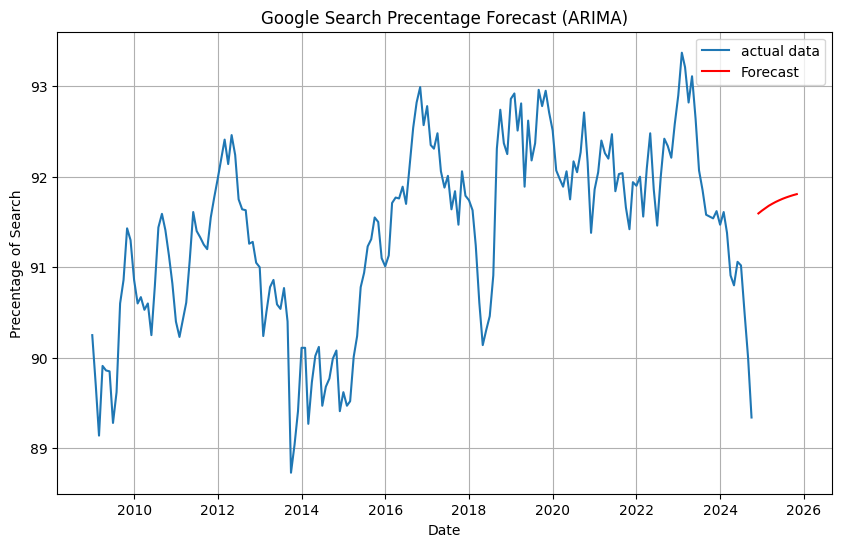

Google's Search Percentage Forecast for the Next Year:
2024-12-31: 91.594488
2025-01-31: 91.625538
2025-02-28: 91.653492
2025-03-31: 91.678661
2025-04-30: 91.701320
2025-05-31: 91.721721
2025-06-30: 91.740088
2025-07-31: 91.756625
2025-08-31: 91.771513
2025-09-30: 91.784917
2025-10-31: 91.796985


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

df = pd.read_csv("search_engine_data.csv")

df.iloc[:,0] = pd.to_datetime(df.iloc[:,0])
df.set_index(df.columns[0],inplace=True)

target_column = df.columns[0]
time_series = df[target_column]

time_series = time_series.dropna()

train_data = time_series[:-12]
test_data = time_series[-12:]

model = ARIMA(train_data,order=(1,1,1)).fit()

forecast_steps = 12
forecast = model.forecast(steps=forecast_steps)

forecast_dates = pd.date_range(time_series.index[-1], periods=forecast_steps + 1, freq="M")[1:]

plt.figure(figsize=(10,6))
plt.plot(time_series,label="actual data")
plt.plot(forecast_dates,forecast,label="Forecast",color="Red")
plt.xlabel("Date")
plt.ylabel("Precentage of Search")
plt.title("Google Search Precentage Forecast (ARIMA)")
plt.legend()
plt.grid()
plt.show()

print("Google's Search Percentage Forecast for the Next Year:")
for date, value in zip(forecast_dates[1:], forecast):
    print(f"{date.strftime('%Y-%m-%d')}: {value:.6f}")